In [1]:
import os
import csv
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Data preprocessing

The structure of the `csv` is as follows:

|workload|AQM|AVG|Small|Small (99$^{\text{th}}$ Percentile)|Large|Load|
|--------|---|---|-----|-----------------------------------|-----|----|
|dc/web  |red/ecnsharp/norm|float|float|float|float|$[0.2, \; 0.9]$|

In [2]:
data = pd.read_csv("data-f13_14.csv")

In [3]:
data = data[data["aqm"] == "norm"]
data8x8_dc = data[data["topology"] == "8x8"].drop(columns=["fig", "topology"])
data4x4_dc = data[data["topology"] == "4x4"].drop(columns=["fig", "topology"])
print(data4x4_dc)

   workload   aqm       avg     small   small99     large  load
26       dc  norm  0.967030  1.039309  2.018649  0.992927   0.2
29       dc  norm  0.936523  1.188076  4.382615  1.097624   0.3
32       dc  norm  0.838976  0.790732  0.910824  0.865392   0.4
35       dc  norm  0.977724  1.080348  0.925897  0.956725   0.5
38       dc  norm  0.939789  0.594801  0.969680  0.942034   0.6
41       dc  norm  0.952561  0.883721  1.008570  0.908636   0.7
44       dc  norm  0.936982  0.846595  0.945686  0.961789   0.8
47       dc  norm  0.973718  0.713275  0.799084  1.005083   0.9


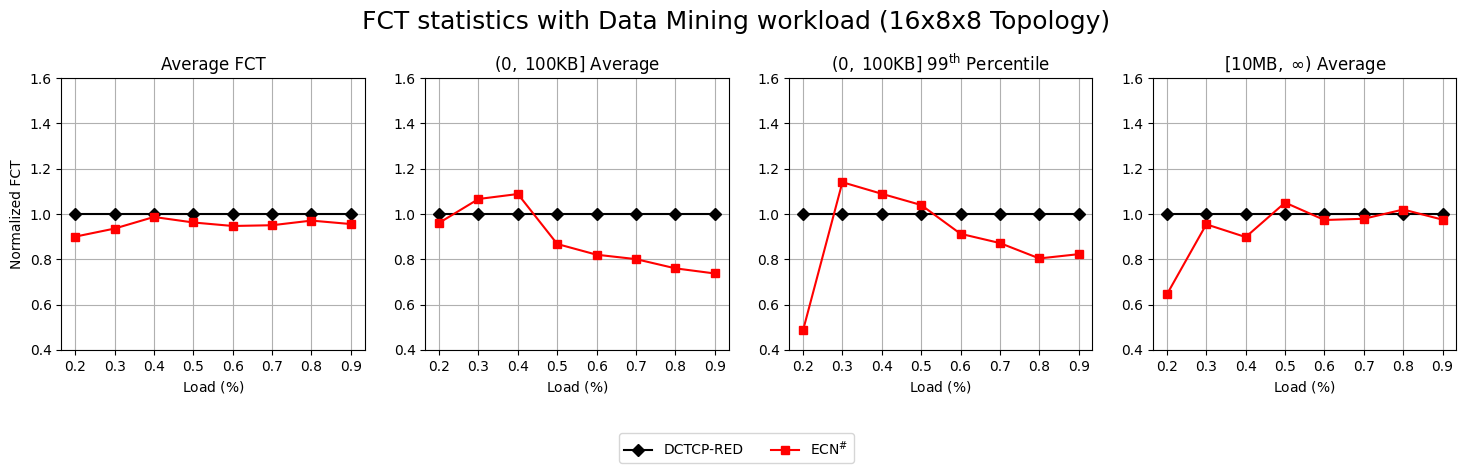

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

interval = [_/10 for _ in range(2, 10)]
norm_data = data8x8_dc
headers = list(norm_data.columns.values)[2:-1]
headers_labels = ["Average FCT", "$(0, \\; 100\\text{KB}]$ Average", "$(0, \\; 100\\text{KB}]$ 99$^{\\text{th}}$ Percentile", "$[10\\text{MB}, \\; \\infty)$ Average"]

for i, ax in enumerate(axes):
    ax.plot(interval, [1 for _ in interval], marker="D", color="black", label="DCTCP-RED")
    ax.plot(norm_data["load"], norm_data[headers[i]], marker="s", color="red", label="ECN$^\\#$")
    ax.set_ylim(0.4, 1.6)
    ax.set_title(headers_labels[i])
    ax.set_xlabel("Load ($\\%$)")
    ax.set_xticks(interval)
    ax.grid()

    if i == 0:
        ax.set_ylabel("Normalized FCT")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=len(labels), frameon=True)
fig.subplots_adjust(bottom=0.2)
fig.suptitle("FCT statistics with Data Mining workload (16x8x8 Topology)", y=1.05, fontsize=18)

fig.savefig("figure13_16x8x8.png", transparent=True)

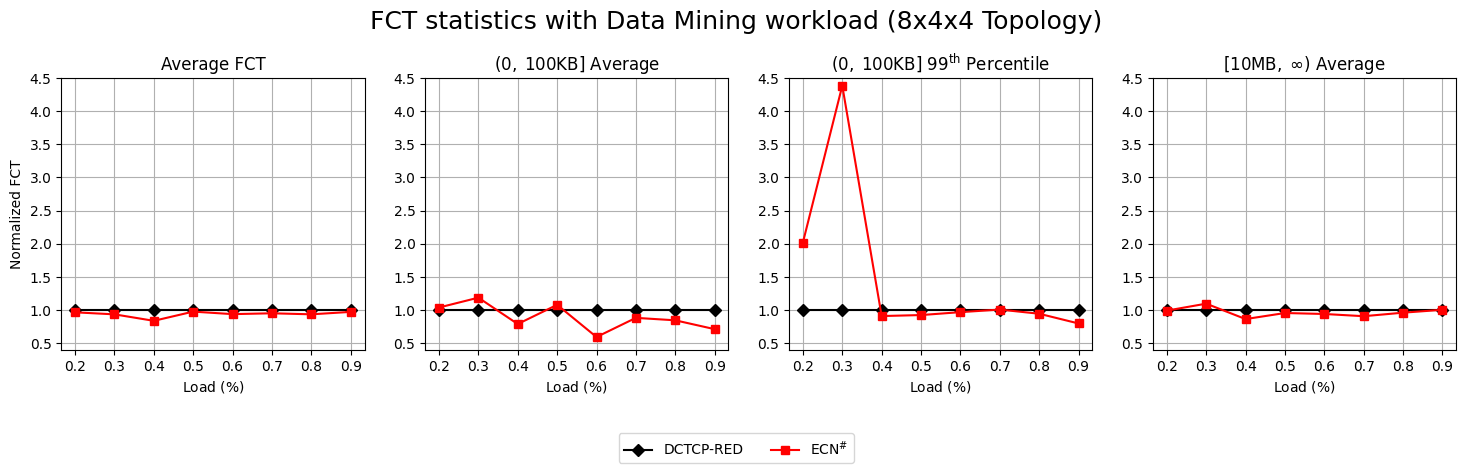

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

interval = [_/10 for _ in range(2, 10)]
norm_data = data4x4_dc
headers = list(norm_data.columns.values)[2:-1]
headers_labels = ["Average FCT", "$(0, \\; 100\\text{KB}]$ Average", "$(0, \\; 100\\text{KB}]$ 99$^{\\text{th}}$ Percentile", "$[10\\text{MB}, \\; \\infty)$ Average"]

for i, ax in enumerate(axes):
    ax.plot(interval, [1 for _ in interval], marker="D", color="black", label="DCTCP-RED")
    ax.plot(norm_data["load"], norm_data[headers[i]], marker="s", color="red", label="ECN$^\\#$")
    ax.set_ylim(0.4, 4.5)
    ax.set_title(headers_labels[i])
    ax.set_xlabel("Load ($\\%$)")
    ax.set_xticks(interval)
    ax.grid()

    if i == 0:
        ax.set_ylabel("Normalized FCT")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=len(labels), frameon=True)
fig.subplots_adjust(bottom=0.2)
fig.suptitle("FCT statistics with Data Mining workload (8x4x4 Topology)", y=1.05, fontsize=18)

fig.savefig("figure13_8x4x4.png", transparent=True)